**Table of contents**
1. [Set up and config](#1)
2. [Phân tích và Tiền xử lý Dữ liệu](#2)
3. [Mô hình và huấn luyện mô hình](#3)
4. [Bias–Variance & VC Dimension](#4)
5. [Evaluate & Visualization](#5)

# 1. Set up and config <a id='1'></a>

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    HuberRegressor,
    RANSACRegressor,
    LinearRegression as SkLinearRegression,
 )
from sklearn.pipeline import Pipeline
import random

# ── Module imports ───────────────────────────────────────────────────────
from preprocessing import prepare_regression_data, load_data, impute_missing, split_data, scale_features
from eda import (
    summarize_dataset,
    summarize_numeric_statistics,
    plot_correlation_heatmap,
    plot_target_distribution,
    plot_feature_vs_target,
    plot_regularization_path,
 )
from models import (
    LinearRegression,
    RidgeRegression,
    LassoRegression,
    ElasticNetRegression,
    PerceptronRegression,
    KernelRidgeRegression,
 )
from utils import (
    k_fold_cv,
    k_fold_cv_metrics,
    build_kfold_indices,
    kfold_rmse_per_model,
    bias_variance_bootstrap,
    forward_stepwise_selection,
    backward_elimination,
    paired_tests_against_best,
    plot_learning_curves,
    plot_residuals,
    plot_predicted_vs_actual,
    loss_curve,
 )


In [ ]:
# Seeding
SEED = 42

# Hyperparameters
LEARNING_RATE = 0.01
MAX_ITER = 10_000

In [ ]:
def set_seed(seed: int) -> None:
  random.seed(seed)
  np.random.default_rng(seed)

set_seed(SEED)

---
# 2. Phân tích và Tiền xử lý Dữ liệu <a id='2'></a>

## 2.1 Load dữ liệu

In [ ]:
from pathlib import Path

data_path = str(Path().resolve().parent.parent / 'data' / 'london_merged.csv')
prepared = prepare_regression_data(
  file_path=data_path,
  target_col='cnt',
  drop_cols=('timestamp',),
  val_size=0.10,
  test_size=0.20,
  random_state=SEED,
 )

df = prepared.df
X = prepared.X
y = prepared.y
feature_names = prepared.feature_names

X_train_raw = prepared.X_train_raw
X_val_raw = prepared.X_val_raw
X_test_raw = prepared.X_test_raw

y_train = prepared.y_train
y_val = prepared.y_val
y_test = prepared.y_test

X_train = prepared.X_train
X_val = prepared.X_val
X_test = prepared.X_test
scaler = prepared.scaler

# Keep a full-dataset standardized matrix for full-dataset CV only.
X_scaled = StandardScaler().fit_transform(X.values)

df.head()

Loaded D:\machine learning\csc14005-introduction-to-machine-learning\lab-1\data\london_merged.csv  →  shape (17414, 10)


,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     17414 non-null  object 
 1   cnt           17414 non-null  int64  
 2   t1            17414 non-null  float64
 3   t2            17414 non-null  float64
 4   hum           17414 non-null  float64
 5   wind_speed    17414 non-null  float64
 6   weather_code  17414 non-null  float64
 7   is_holiday    17414 non-null  float64
 8   is_weekend    17414 non-null  float64
 9   season        17414 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 1.3+ MB


In [6]:
df.describe()

,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
count,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,1143.101642,12.468091,11.520836,72.324954,15.913063,2.722752,0.022051,0.285403,1.492075
std,1085.108068,5.571818,6.615145,14.313186,7.894570,2.341163,0.146854,0.451619,1.118911
min,0.000000,-1.500000,-6.000000,20.500000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,257.000000,8.000000,6.000000,63.000000,10.000000,1.000000,0.000000,0.000000,0.000000
50%,844.000000,12.500000,12.500000,74.500000,15.000000,2.000000,0.000000,0.000000,1.000000
75%,1671.750000,16.000000,16.000000,83.000000,20.500000,3.000000,0.000000,1.000000,2.000000
max,7860.000000,34.000000,34.000000,100.000000,56.500000,26.000000,1.000000,1.000000,3.000000


## 2.2 Xử lý giá trị còn thiếu (Missing Values)

In [ ]:
missing_summary = summarize_dataset(df)
print('Missing value counts:')
print(missing_summary if not missing_summary.empty else 'None')


Missing value counts:
None


In [ ]:
print('Missing values were imputed inside prepare_regression_data() using training statistics.')

No missing values found.


## 2.3 Khám phá dữ liệu (EDA)

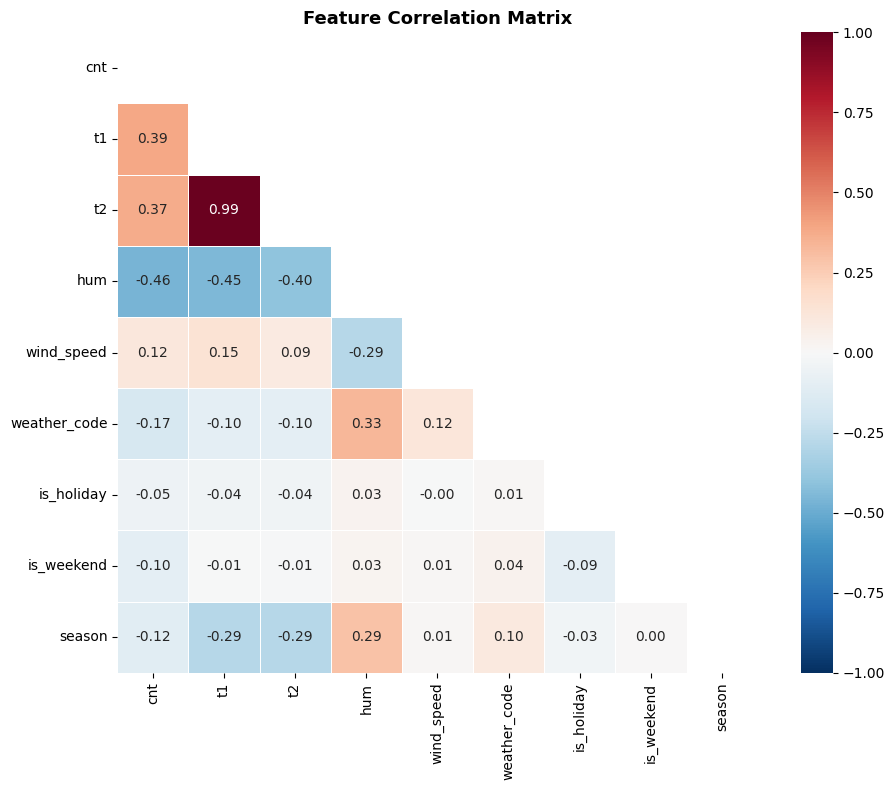

In [ ]:
feature_stats = summarize_numeric_statistics(X)
print('Descriptive statistics for numeric features:')
feature_stats

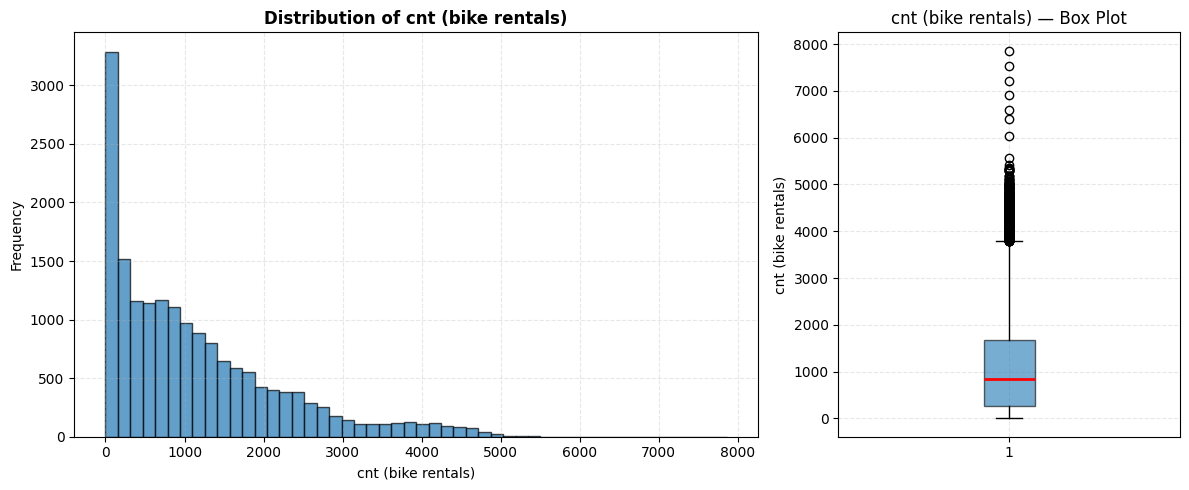

In [ ]:
plot_correlation_heatmap(df)
plot_target_distribution(y.values if hasattr(y, 'values') else y, target_name='cnt (bike rentals)')
plot_feature_vs_target(
    X.values if hasattr(X, 'values') else X,
    y.values if hasattr(y, 'values') else y,
    feature_names=feature_names,
 )


In [ ]:
plot_feature_vs_target(
    X.values if hasattr(X, 'values') else X,
    y.values if hasattr(y, 'values') else y,
    feature_names=feature_names,
 )


### 2.3.1 Feature vs target

## 2.4 Chuẩn hóa (Standardization)

In [11]:
# Separate features and target; drop non-numeric / ID columns
feature_names = [col for col in df.columns if col not in ('timestamp', 'cnt')]
X = df[feature_names].values
y = df['cnt'].values

print(f'Features ({len(feature_names)}): {feature_names}')
print(f'X shape: {X.shape}  |  y shape: {y.shape}')

# X_scaled fitted on the full dataset is kept ONLY for whole-dataset CV.
# For train/val/test experiments the scaler is re-fitted on training data only (next cell).
X_scaled = StandardScaler().fit_transform(X)


Features (8): ['t1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season']
X shape: (17414, 8)  |  y shape: (17414,)


## 2.5 Chia dữ liệu: Train (70%) / Validation (10%) / Test (20%)

In [12]:
# Train 70 % / Validation 10 % / Test 20 %
# IMPORTANT: split raw features first, then fit the scaler on X_train only
# to prevent data leakage into val / test sets.
X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test = split_data(
    X, y, val_size=0.10, test_size=0.20, random_state=SEED
)

scaler, X_train, X_val, X_test = scale_features(X_train_raw, X_val_raw, X_test_raw)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}  y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}  y_test:  {y_test.shape}')


Split sizes -> train: 12189  val: 1742  test: 3483
X_train: (12189, 8)  y_train: (12189,)
X_val:   (1742, 8)  y_val:   (1742,)
X_test:  (3483, 8)  y_test:  (3483,)


---
# 3. Mô hình và huấn luyện mô hình <a id='3'></a>

## 3.1 Base

The `Regression` abstract base class is defined in `models/base.py`.

In [13]:
# Regression base class and all model classes are imported from `models/`
# at the top of this notebook.  No inline definitions needed.


---

## 3.2 Hồi Quy Với Regularization: Kiểm Soát Độ Phức Tạp & Chọn Feature

**Mục đích:** 
- Tìm hiểu cách **kiểm soát độ phức tạp** của mô hình để tránh overfitting
- So sánh các phương pháp regularization (L1, L2, L1+L2)
- Tìm ra **feature nào thực sự quan trọng** cho dự đoán

**Nội dung:**
- **[3.2.4]** Ridge (L2) vs Lasso (L1): Chọn tham số tối ưu bằng k-fold CV
- **[3.2.5]** Regularization Path: Thấy rõ cách hệ số thay đổi
- **[3.2.6]** Elastic Net: Kết hợp cả L1 và L2
- **[3.2.7]** Feature Selection: So sánh 3 cách chọn feature

### 3.2.1 Linear Regression

In [14]:
# LinearRegression is imported from models/linear_reg.py
# Supports solver='normal' (closed-form lstsq) and solver='gradient_descent'.


### 3.2.2 Ridge Regression (L2 Regularization)

In [15]:
# RidgeRegression is imported from models/ridge_reg.py


### 3.2.3 Lasso Regression (L1 — Feature Selection)

In [16]:
# LassoRegression is imported from models/lasso_reg.py


In [17]:
# k_fold_cv được import từ utils.py

In [18]:
# ElasticNetRegression is imported from models/elastic_net.py


In [ ]:
# compute_ridge_path / compute_lasso_path logic is encapsulated in
# eda.plot_regularization_path() — see section [3.2.5] below.


### 3.2.4 Ridge & Lasso: Cài đặt và Chọn Tham Số Tối Ưu (k-fold CV)

Phần này so sánh hai phương pháp regularization phổ biến:

**Ridge Regression (L2):** Thu nhỏ tất cả các hệ số về phía 0, nhưng không loại bỏ hoàn toàn các feature.  
**Lasso Regression (L1):** Có khả năng loại bỏ hoàn toàn một số feature (đặt hệ số = 0 chính xác).

Quy trình:
1. Thử các giá trị tham số (λ) khác nhau
2. Dùng k-fold cross-validation (k=10) để tìm λ tốt nhất
3. Huấn luyện mô hình cuối cùng với λ tối ưu
4. So sánh hệ số giữa Linear Regression, Ridge, và Lasso

In [20]:
# Linear Regression (baseline)
lr = LinearRegression(solver='normal')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
m_lr = lr.evaluate(y_pred_lr, y_test)
print('Linear Regression:', m_lr)

Linear Regression: {'MSE': 898089.1885726402, 'RMSE': 947.675676891963, 'MAE': 697.7968533146347, 'R2': 0.250494925763039}


In [21]:
# Robust Regression: Huber & RANSAC
from sklearn.linear_model import HuberRegressor, RANSACRegressor, LinearRegression as SkLinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print('--- Robust Regression: Huber & RANSAC ---')

huber_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("huber", HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=1000)),
    ]
)

huber_model.fit(X_train, y_train)
y_pred_huber = huber_model.predict(X_test)
m_huber = lr.evaluate(y_pred_huber, y_test)
print('Huber Regression:', m_huber)

ransac_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("ransac", RANSACRegressor(estimator=SkLinearRegression(), random_state=SEED)),
    ]
)

ransac_model.fit(X_train, y_train)
y_pred_ransac = ransac_model.predict(X_test)
m_ransac = lr.evaluate(y_pred_ransac, y_test)
print('RANSAC Regression:', m_ransac)


--- Robust Regression: Huber & RANSAC ---
Huber Regression: {'MSE': 954938.3644712622, 'RMSE': 977.2094782958576, 'MAE': 660.3546826608555, 'R2': 0.2030511458530213}
RANSAC Regression: {'MSE': 1007684.7107553164, 'RMSE': 1003.8350017584147, 'MAE': 666.3316355378518, 'R2': 0.15903140406079408}


In [22]:
# Ridge — tune alpha using k-fold CV (k=10)
print('--- Ridge tuning (k-fold CV, k=10) ---')
best_ridge = None
best_alpha_ridge = None
best_mse_ridge = float('inf')
best_std_ridge = 0

for alpha in [0.1, 1.0, 10.0, 100.0, 1000.0, 5000.0]:
    mean_mse, std_mse = k_fold_cv(RidgeRegression, {'alpha': alpha}, X_train, y_train, k=10)
    print(f'  alpha = {alpha:<6}  CV MSE = {mean_mse:.2f} ± {std_mse:.2f}')
    if mean_mse < best_mse_ridge:
        best_mse_ridge = mean_mse
        best_std_ridge = std_mse
        best_alpha_ridge = alpha

# Train final Ridge model with best alpha on full training set
best_ridge = RidgeRegression(alpha=best_alpha_ridge)
best_ridge.fit(X_train, y_train)

y_pred_ridge = best_ridge.predict(X_test)
m_ridge = best_ridge.evaluate(y_pred_ridge, y_test)
print(f'\nBest Ridge (alpha={best_alpha_ridge}): CV MSE = {best_mse_ridge:.2f} ± {best_std_ridge:.2f}')
print(f'Best Ridge Test performance: {m_ridge}')

--- Ridge tuning (k-fold CV, k=10) ---
  alpha = 0.1     CV MSE = 846485.89 ± 50880.89
  alpha = 1.0     CV MSE = 846484.96 ± 50877.81
  alpha = 10.0    CV MSE = 846484.88 ± 50851.22
  alpha = 100.0   CV MSE = 846732.81 ± 50785.54
  alpha = 1000.0  CV MSE = 849015.60 ± 51600.31
  alpha = 5000.0  CV MSE = 866724.60 ± 53535.84

Best Ridge (alpha=10.0): CV MSE = 846484.88 ± 50851.22
Best Ridge Test performance: {'MSE': 898123.7542766692, 'RMSE': 947.6939138121913, 'MAE': 697.7714682412635, 'R2': 0.2504660787722346}


In [23]:
# Lasso — tune alpha using k-fold CV (k=10) + feature selection
print('--- Lasso tuning (k-fold CV, k=10) ---')
best_lasso = None
best_alpha_lasso = None
best_mse_lasso = float('inf')
best_std_lasso = 0

for alpha in [0.01, 0.1, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0]:
    mean_mse, std_mse = k_fold_cv(LassoRegression, {'alpha': alpha}, X_train, y_train, k=10)
    # Count non-zero features for this alpha (using a temporary model)
    temp_model = LassoRegression(alpha=alpha)
    temp_model.fit(X_train, y_train)
    n_kept = np.count_nonzero(temp_model.coef_)
    print(f'  alpha = {alpha:<5}  CV MSE = {mean_mse:.2f} ± {std_mse:.2f}  features kept = {n_kept}/{len(feature_names)}')
    if mean_mse < best_mse_lasso:
        best_mse_lasso = mean_mse
        best_std_lasso = std_mse
        best_alpha_lasso = alpha

# Train final Lasso model with best alpha on full training set
best_lasso = LassoRegression(alpha=best_alpha_lasso)
best_lasso.fit(X_train, y_train)

y_pred_lasso = best_lasso.predict(X_test)
m_lasso = best_lasso.evaluate(y_pred_lasso, y_test)
print(f'\nBest Lasso (alpha={best_alpha_lasso}): CV MSE = {best_mse_lasso:.2f} ± {best_std_lasso:.2f}')
print(f'Best Lasso Test performance: {m_lasso}')
print(f'Coefficients: {dict(zip(feature_names, best_lasso.coef_.round(4)))}')
print(f'Dropped features: {[f for f, c in zip(feature_names, best_lasso.coef_) if c == 0]}')

--- Lasso tuning (k-fold CV, k=10) ---
  alpha = 0.01   CV MSE = 846486.02 ± 50880.36  features kept = 8/8
  alpha = 0.1    CV MSE = 846486.74 ± 50872.61  features kept = 8/8
  alpha = 1.0    CV MSE = 846543.77 ± 50795.41  features kept = 8/8
  alpha = 5.0    CV MSE = 846719.57 ± 50826.24  features kept = 7/8
  alpha = 10.0   CV MSE = 846871.38 ± 50957.81  features kept = 7/8
  alpha = 20.0   CV MSE = 847472.19 ± 51217.62  features kept = 7/8
  alpha = 50.0   CV MSE = 850871.09 ± 51677.07  features kept = 6/8
  alpha = 100.0  CV MSE = 858330.09 ± 52206.55  features kept = 3/8

Best Lasso (alpha=0.01): CV MSE = 846486.02 ± 50880.36
Best Lasso Test performance: {'MSE': 898090.2420411443, 'RMSE': 947.6762327088003, 'MAE': 697.7955587804387, 'R2': 0.2504940465853367}
Coefficients: {'t1': np.float64(389.5429), 't2': np.float64(-125.0791), 'hum': np.float64(-406.8214), 'wind_speed': np.float64(-30.0449), 'weather_code': np.float64(-15.9732), 'is_holiday': np.float64(-35.4259), 'is_weekend': 


DETAILED COEFFICIENT COMPARISON
Feature                  Linear        Ridge        Lasso     Δ Ridge%     Δ Lasso%   Lasso Zero
----------------------------------------------------------------------------------------------------
t1                     390.0983     369.5029     389.5429         -5.3         -0.1           NO
t2                    -125.6231    -105.4762    -125.0791         16.0          0.4           NO
hum                   -406.8046    -407.2582    -406.8214         -0.1         -0.0           NO
wind_speed             -30.0761     -29.0015     -30.0449          3.6          0.1           NO
weather_code           -15.9796     -15.9662     -15.9732          0.1          0.0           NO
is_holiday             -35.4299     -35.4492     -35.4259         -0.1          0.0           NO
is_weekend             -89.5763     -89.4431     -89.5694          0.1          0.0           NO
season                  68.5335      68.4702      68.5294         -0.1         -0.0       

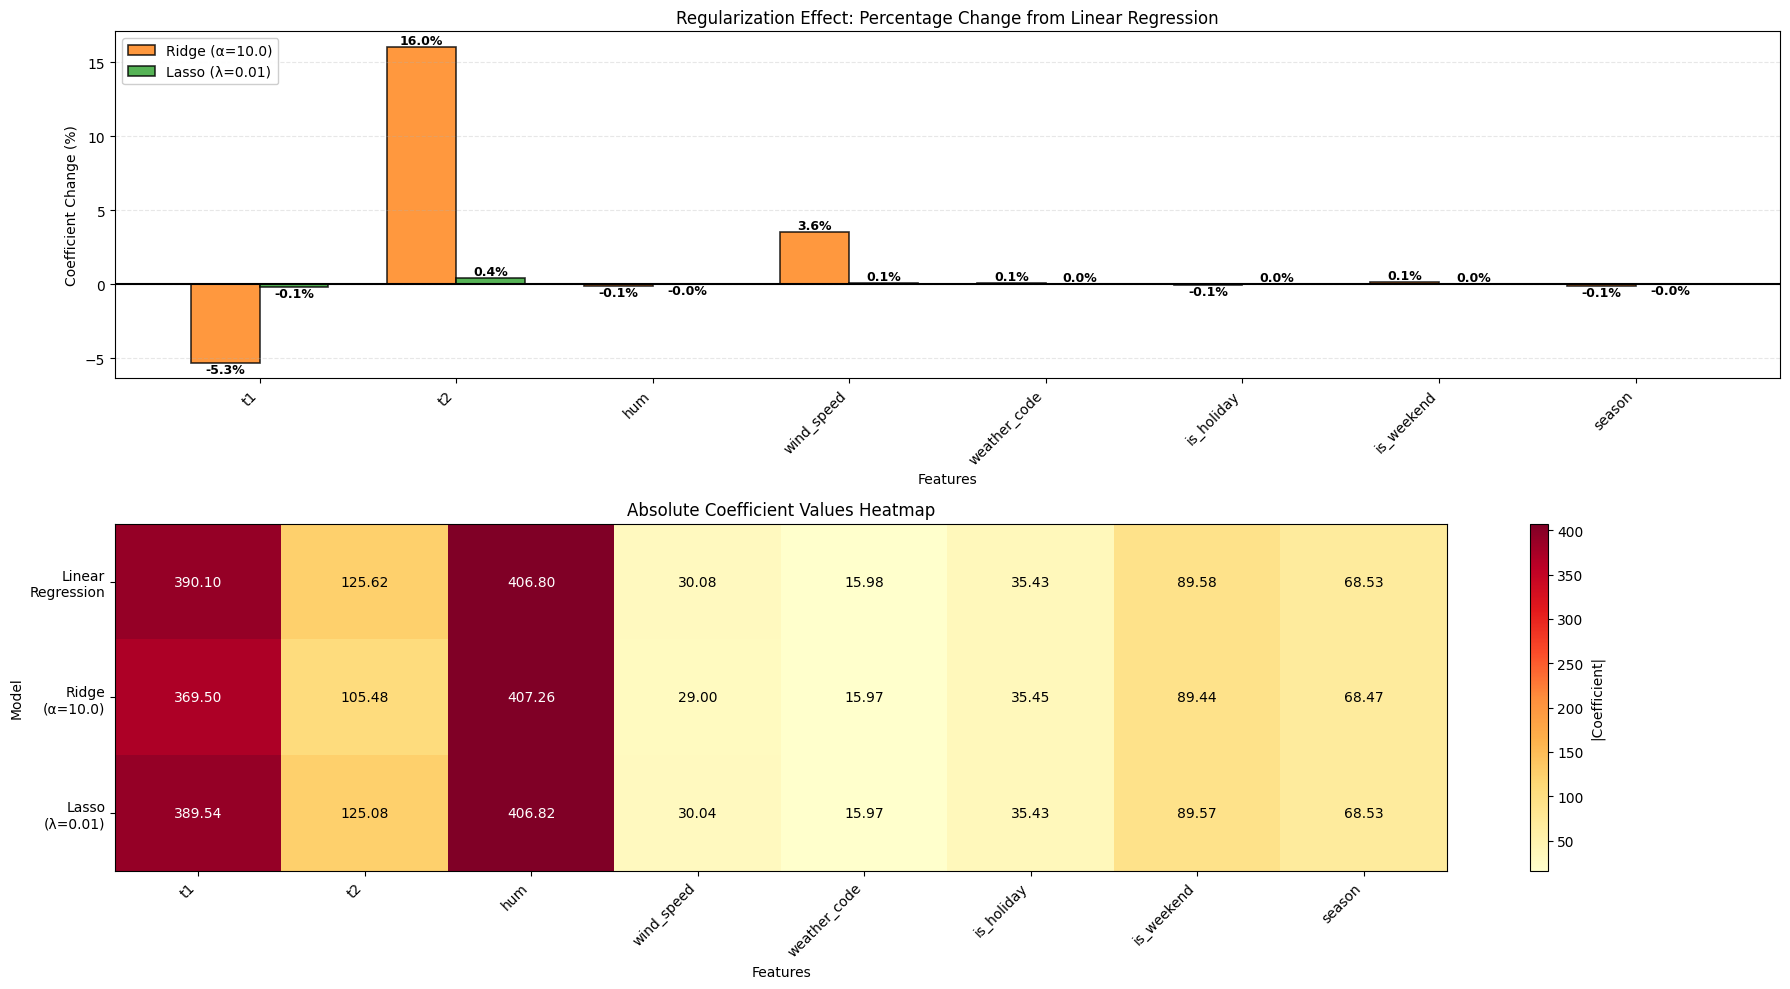

In [24]:
# === % Change + Heatmap Analysis (Linear vs Ridge vs Lasso) ===

# ===== 1. Percentage change relative to Linear Regression =====
eps = 1e-10
linear_coef = lr.coef_

pct_change_ridge = (best_ridge.coef_ - linear_coef) / (np.abs(linear_coef) + eps) * 100
pct_change_lasso = (best_lasso.coef_ - linear_coef) / (np.abs(linear_coef) + eps) * 100

# ===== 2. Visualization =====
fig = plt.figure(figsize=(18, 10))

# --- Subplot 1: Percentage Change ---
ax1 = plt.subplot(2, 1, 1)

x = np.arange(len(feature_names))
width = 0.35

bars_ridge = ax1.bar(
    x - width / 2,
    pct_change_ridge,
    width,
    label=f'Ridge (α={best_alpha_ridge})',
    color='#ff7f0e',
    alpha=0.8,
    edgecolor='black',
    linewidth=1.2
)

bars_lasso = ax1.bar(
    x + width / 2,
    pct_change_lasso,
    width,
    label=f'Lasso (λ={best_alpha_lasso})',
    color='#2ca02c',
    alpha=0.8,
    edgecolor='black',
    linewidth=1.2
)

ax1.set(
    xlabel='Features',
    ylabel='Coefficient Change (%)',
    title='Regularization Effect: Percentage Change from Linear Regression'
)

ax1.set_xticks(x)
ax1.set_xticklabels(feature_names, rotation=45, ha='right')
ax1.axhline(0, color='black', linewidth=1.5)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

ax1.legend(loc='upper left', framealpha=0.95)

# Annotate bars
for bars in (bars_ridge, bars_lasso):
    for bar in bars:
        value = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f'{value:.1f}%',
            ha='center',
            va='bottom' if value > 0 else 'top',
            fontsize=9,
            fontweight='bold'
        )

# --- Subplot 2: Heatmap of absolute coefficients ---
ax2 = plt.subplot(2, 1, 2)

coef_matrix = np.vstack([
    np.abs(linear_coef),
    np.abs(best_ridge.coef_),
    np.abs(best_lasso.coef_)
])

model_labels = [
    'Linear\nRegression',
    f'Ridge\n(α={best_alpha_ridge})',
    f'Lasso\n(λ={best_alpha_lasso})'
]

im = ax2.imshow(coef_matrix, cmap='YlOrRd', aspect='auto')

ax2.set_xticks(np.arange(len(feature_names)))
ax2.set_yticks(np.arange(len(model_labels)))

ax2.set_xticklabels(feature_names, rotation=45, ha='right')
ax2.set_yticklabels(model_labels)

ax2.set(
    xlabel='Features',
    ylabel='Model',
    title='Absolute Coefficient Values Heatmap'
)

# Annotate heatmap
threshold = coef_matrix.max() * 0.5
for i in range(coef_matrix.shape[0]):
    for j in range(coef_matrix.shape[1]):
        value = coef_matrix[i, j]
        color = 'white' if value > threshold else 'black'
        ax2.text(j, i, f'{value:.2f}', ha='center', va='center', color=color)

plt.colorbar(im, ax=ax2, label='|Coefficient|')

plt.tight_layout()

# ===== 3. Detailed comparison table =====
print('\n' + '=' * 100)
print('DETAILED COEFFICIENT COMPARISON')
print('=' * 100)

header = f'{"Feature":<18} {"Linear":>12} {"Ridge":>12} {"Lasso":>12} {"Δ Ridge%":>12} {"Δ Lasso%":>12} {"Lasso Zero":>12}'
print(header)
print('-' * 100)

for i, feat in enumerate(feature_names):
    lin = linear_coef[i]
    ridge = best_ridge.coef_[i]
    lasso = best_lasso.coef_[i]

    print(
        f'{feat:<18} {lin:>12.4f} {ridge:>12.4f} {lasso:>12.4f} '
        f'{pct_change_ridge[i]:>12.1f} {pct_change_lasso[i]:>12.1f} '
        f'{"YES ✓" if abs(lasso) < eps else "NO":>12}'
    )

# ===== 4. Summary statistics =====
print('\n' + '=' * 100)
print('SUMMARY STATISTICS')
print('=' * 100)

ridge_avg = np.mean(np.abs(pct_change_ridge))
lasso_avg = np.mean(np.abs(pct_change_lasso))
ridge_max = np.max(np.abs(pct_change_ridge))
lasso_max = np.max(np.abs(pct_change_lasso))

lasso_zero_count = np.sum(np.abs(best_lasso.coef_) < eps)

print('\nRIDGE (L2):')
print(f'Average shrinkage: {ridge_avg:.2f}%')
print(f'Maximum shrinkage: {ridge_max:.2f}% ({feature_names[np.argmax(np.abs(pct_change_ridge))]})')
print('All coefficients non-zero: Yes')

print('\nLASSO (L1):')
print(f'Average shrinkage: {lasso_avg:.2f}%')
print(f'Maximum shrinkage: {lasso_max:.2f}% ({feature_names[np.argmax(np.abs(pct_change_lasso))]})')
print(f'Zero coefficients: {lasso_zero_count}/{len(feature_names)} ({lasso_zero_count/len(feature_names)*100:.1f}%)')

if lasso_zero_count > 0:
    eliminated_features = [f for f, c in zip(feature_names, best_lasso.coef_) if abs(c) < eps]
    print(f'Eliminated features: {eliminated_features}')
else:
    print('Eliminated features: None')

print('\nINTERPRETATION:')
if ridge_avg < 10 and lasso_avg < 10:
    print('Minimal regularization effect (<10% change)')
    print('Linear model is already well-fitted')
else:
    print('Regularization significantly affects coefficients')

print('\nMODEL PERFORMANCE:')
print(f'Linear MSE: {m_lr["MSE"]:.2f}')
print(f'Ridge MSE:  {m_ridge["MSE"]:.2f} ({(m_ridge["MSE"]/m_lr["MSE"]-1)*100:+.2f}%)')
print(f'Lasso MSE:  {m_lasso["MSE"]:.2f} ({(m_lasso["MSE"]/m_lr["MSE"]-1)*100:+.2f}%)')

print('=' * 100)

### 3.2.5 Regularization Path: Theo dõi Hệ Số Khi λ Thay Đổi

Mục đích: Hiểu rõ **cách hệ số thay đổi** khi tăng sức mạnh của regularization (λ từ nhỏ đến lớn).

**Ridge path:**
- Hệ số giảm dần một cách mượt mà
- Không bao giờ bằng 0 chính xác (chỉ sát 0)

**Lasso path:**
- Hệ số giảm không đều đặn (gợi sóng)
- Một số hệ số nhảy thẳng bằng 0 khi λ vượt ngưỡng nào đó
- Dùng "warm start": dùng nghiệm cũ để tính manh nghiệm mới → nhanh hơn

So sánh hai path giúp bạn thấy sự khác biệt giữa L2 (mềm) và L1 (cứng).

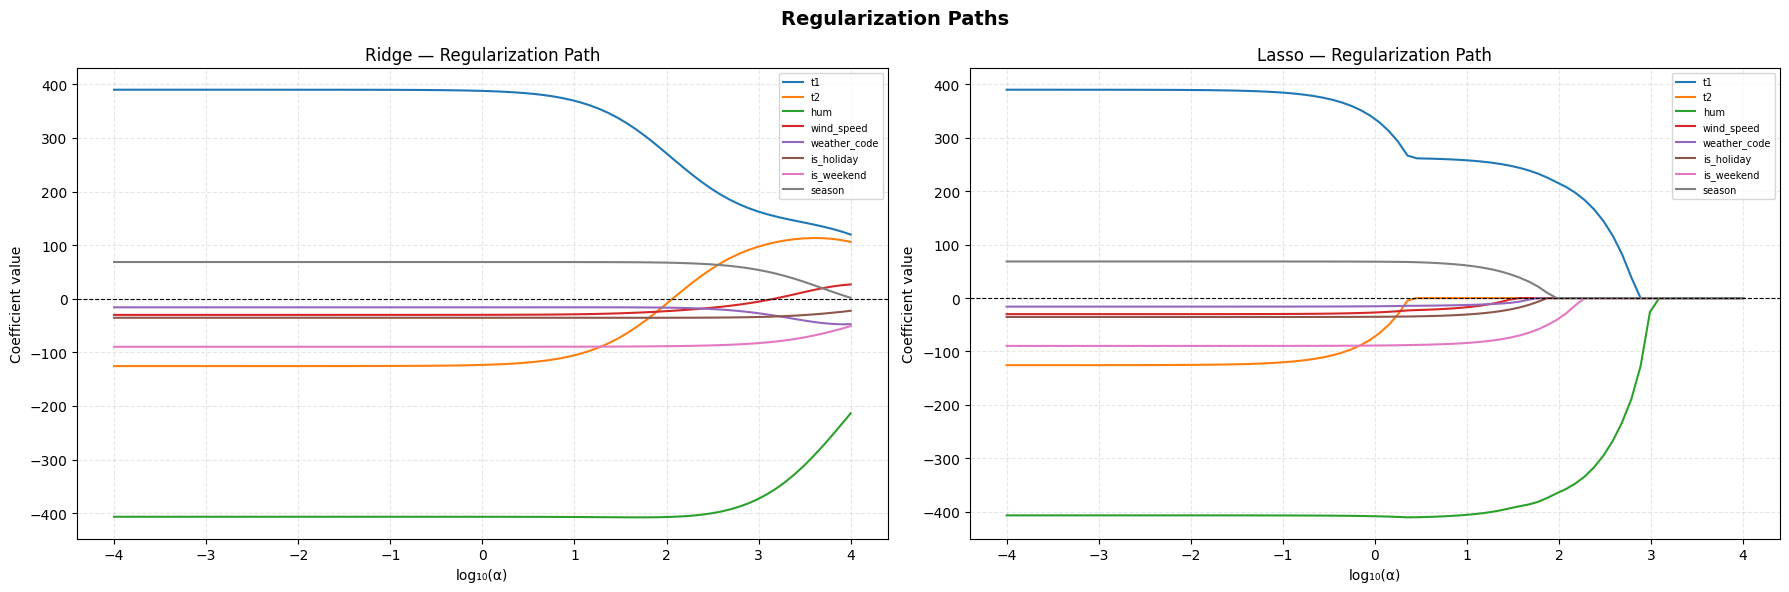

In [25]:
plot_regularization_path(
    X_train, y_train,
    feature_names=feature_names,
    alphas=np.logspace(-4, 4, 80),
)


### 3.2.6 Elastic Net: Kết Hợp L1 và L2 - Tìm Vùng Tối Ưu

Elastic Net = Ridge (L2) + Lasso (L1)

$$E(\mathbf{w}) = \frac{1}{2}\|\mathbf{t}-\Phi\mathbf{w}\|^2 + \lambda_1\|\mathbf{w}\|_1 + \frac{\lambda_2}{2}\|\mathbf{w}\|_2^2$$

Ưu điểm: Kết hợp khả năng **loại feature** (từ Lasso) + **mềm mại** (từ Ridge)

Quy trình:
1. Tạo lưới giá trị: thử tất cả cặp (λ₁, λ₂) từ 10⁻³ đến 10¹
2. Với mỗi cặp (λ₁, λ₂): huấn luyện mô hình, đánh giá trên validation set
3. Vẽ **heatmap**: điểm tối ưu sẽ là nơi MSE thấp nhất (thường trông như "vùng lõm")
4. Lấy tham số tốt nhất để huấn luyện mô hình cuối cùng

=== Elastic Net: Hyperparameter Optimization (λ1, λ2) ===
Best λ1=0.001000, λ2=0.051795, Val MSE=898540.3928

Best Elastic Net (λ1=0.001000, λ2=0.051795): {'MSE': 900335.5956689088, 'RMSE': 948.8601560129442, 'MAE': 700.7722294314746, 'R2': 0.2486201748598117}


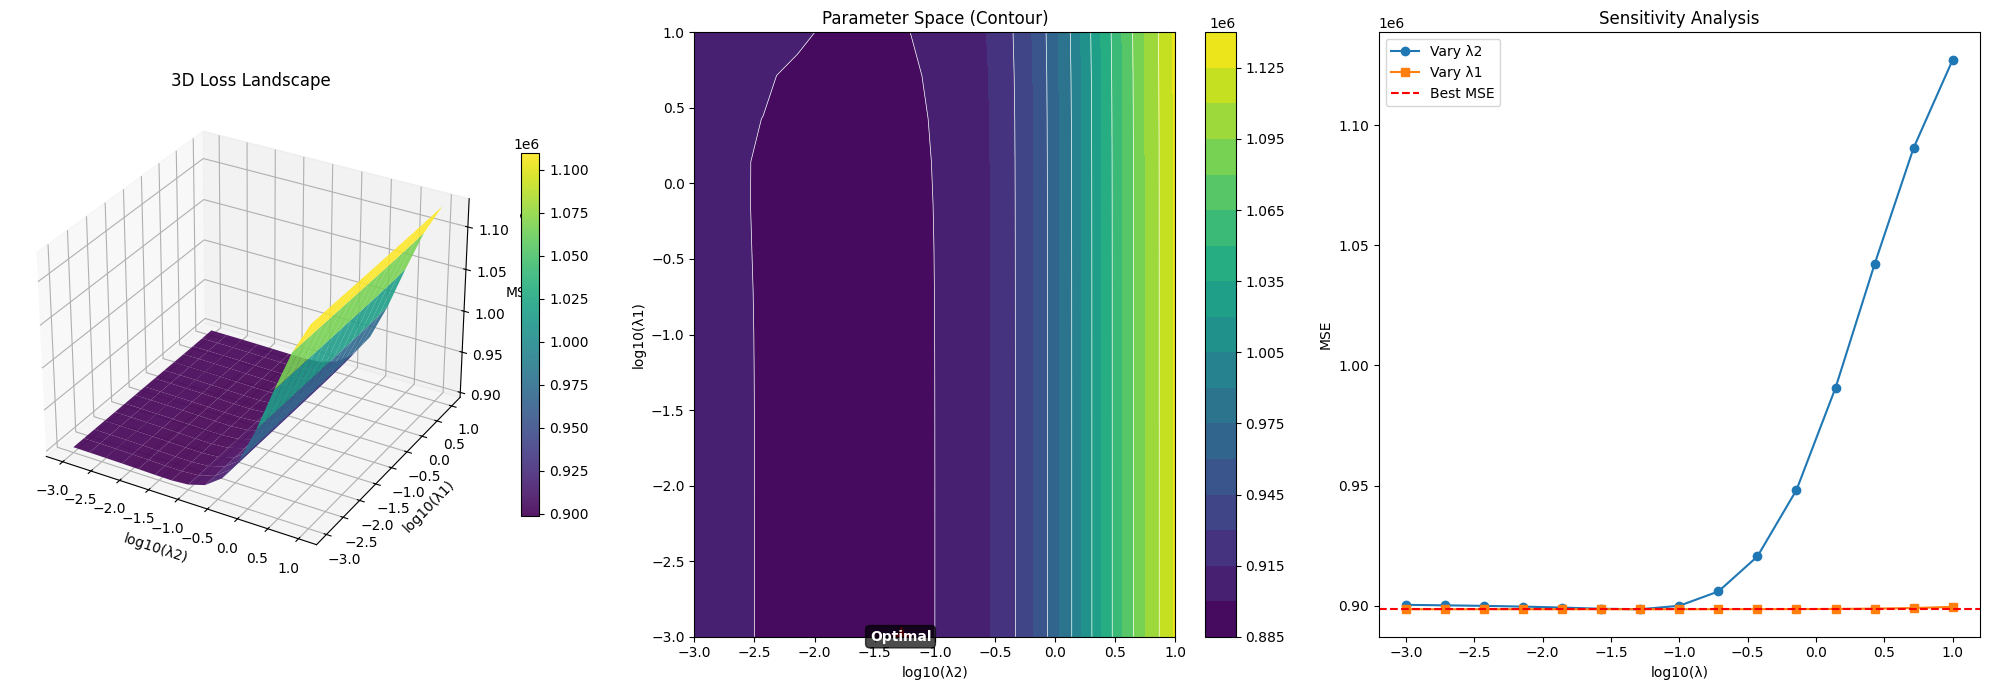

In [26]:
# Elastic Net: Hyperparameter Optimization (λ1, λ2)
print("=== Elastic Net: Hyperparameter Optimization (λ1, λ2) ===")

# Hyperparameter grid
lambda1_values = np.logspace(-3, 1, 15)
lambda2_values = np.logspace(-3, 1, 15)

mse_grid = np.zeros((len(lambda1_values), len(lambda2_values)))

# Grid search
for i, l1 in enumerate(lambda1_values):
    for j, l2 in enumerate(lambda2_values):
        model = ElasticNetRegression(lambda1=l1, lambda2=l2, max_iter=500)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        mse_grid[i, j] = np.mean((y_pred - y_val) ** 2)

# Best parameters
best_idx = np.unravel_index(np.argmin(mse_grid), mse_grid.shape)
best_l1 = lambda1_values[best_idx[0]]
best_l2 = lambda2_values[best_idx[1]]
best_mse = mse_grid[best_idx]

print(f"Best λ1={best_l1:.6f}, λ2={best_l2:.6f}, Val MSE={best_mse:.4f}")

# Log-scale transformation
log_l1 = np.log10(lambda1_values)
log_l2 = np.log10(lambda2_values)

L2_grid, L1_grid = np.meshgrid(log_l2, log_l1)

# ===== Visualization =====
fig = plt.figure(figsize=(20, 7))

# --- 1. 3D Surface ---
ax1 = fig.add_subplot(1, 3, 1, projection='3d')

surf = ax1.plot_surface(
    L2_grid, L1_grid, mse_grid,
    cmap='viridis', alpha=0.9, linewidth=0.2
)

ax1.set_xlabel('log10(λ2)')
ax1.set_ylabel('log10(λ1)')
ax1.set_zlabel('MSE')
ax1.set_title('3D Loss Landscape')

fig.colorbar(surf, ax=ax1, shrink=0.6)

# --- 2. Contour Plot ---
ax2 = fig.add_subplot(1, 3, 2)

contour = ax2.contourf(L2_grid, L1_grid, mse_grid, levels=20, cmap='viridis')
ax2.contour(L2_grid, L1_grid, mse_grid, colors='white', linewidths=0.5)

ax2.scatter(
    np.log10(best_l2),
    np.log10(best_l1),
    color='red', marker='*', s=200
)

ax2.set_xlabel('log10(λ2)')
ax2.set_ylabel('log10(λ1)')
ax2.set_title('Parameter Space (Contour)')

# Add text annotation for optimal point
ax2.text(
    np.log10(best_l2), 
    np.log10(best_l1),
    'Optimal',
    ha='center', va='center',
    fontsize=10, fontweight='bold',
    color='white',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7)
)

fig.colorbar(contour, ax=ax2)

# --- 3. 1D Sensitivity ---
ax3 = fig.add_subplot(1, 3, 3)
best_l1_idx, best_l2_idx = best_idx

mse_l2_slice = mse_grid[best_l1_idx, :]
mse_l1_slice = mse_grid[:, best_l2_idx]

ax3.plot(log_l2, mse_l2_slice, 'o-', label='Vary λ2')
ax3.plot(log_l1, mse_l1_slice, 's-', label='Vary λ1')
ax3.axhline(best_mse, linestyle='--', color='red', label='Best MSE')
ax3.set_xlabel('log10(λ)')
ax3.set_ylabel('MSE')
ax3.set_title('Sensitivity Analysis')
ax3.legend()

plt.tight_layout()

# ===== Final training =====
best_model = ElasticNetRegression(
    lambda1=best_l1,
    lambda2=best_l2,
    max_iter=1000
)
best_model.fit(X_train, y_train)
y_test_pred_enet = best_model.predict(X_test)
m_enet = best_model.evaluate(y_test_pred_enet, y_test)
print(f'\nBest Elastic Net (λ1={best_l1:.6f}, λ2={best_l2:.6f}): {m_enet}')

### 3.2.7 Lựa Chọn Feature: So Sánh 3 Chiến Lược

Mục đích: Tìm ra **tập hợp feature tốt nhất** (ít mà hiệu quả) bằng 3 phương pháp khác nhau.

**1. Forward Stepwise Selection (Xây dựng từ dưới lên):**
- Bắt đầu: không có feature nào
- Mỗi bước: thêm 1 feature tốt nhất (làm giảm MSE nhất)
- Kết thúc: khi thêm feature mới không tốt nữa

**2. Backward Elimination (Loại từ trên xuống):**
- Bắt đầu: có tất cả feature
- Mỗi bước: loại 1 feature "xấu nhất" (loại nó làm giảm MSE)
- Kết thúc: khi loại feature nào còn lại cũng làm tệ hơn

**3. Lasso-based Feature Selection:**
- Dùng tham số λ tối ưu từ Lasso ở [3.2.4]
- Feature được giữ = những cái có hệ số ≠ 0
- Đơn giản, nhanh, cho kết quả cụ thể

**So Sánh:** Xem 3 phương pháp chọn feature nào + số lượng bao nhiêu + MSE cuối cùng như thế nào

In [27]:
# forward_stepwise_selection() và backward_elimination() được import từ utils.py


 So sanh ket qua Feature Selection

--- Forward Stepwise Selection ---
  Step 1: +"hum" -> Val MSE = 973996.94
  Step 2: +"t1" -> Val MSE = 920501.96
  Step 3: +"is_weekend" -> Val MSE = 910353.62
  Step 4: +"season" -> Val MSE = 904743.54
  Step 5: +"is_holiday" -> Val MSE = 902183.41
  ...
  Best: 7 features -> ['hum', 't1', 'is_weekend', 'season', 'is_holiday', 'weather_code', 'wind_speed']

--- Backward Elimination ---
  Step 1: -"t2" -> Val MSE = 900213.28
  ...
  Best: 7 features -> ['t1', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season']

--- Lasso-based Feature Selection ---
  Selected (8): ['t1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season']
  Dropped  (0): []


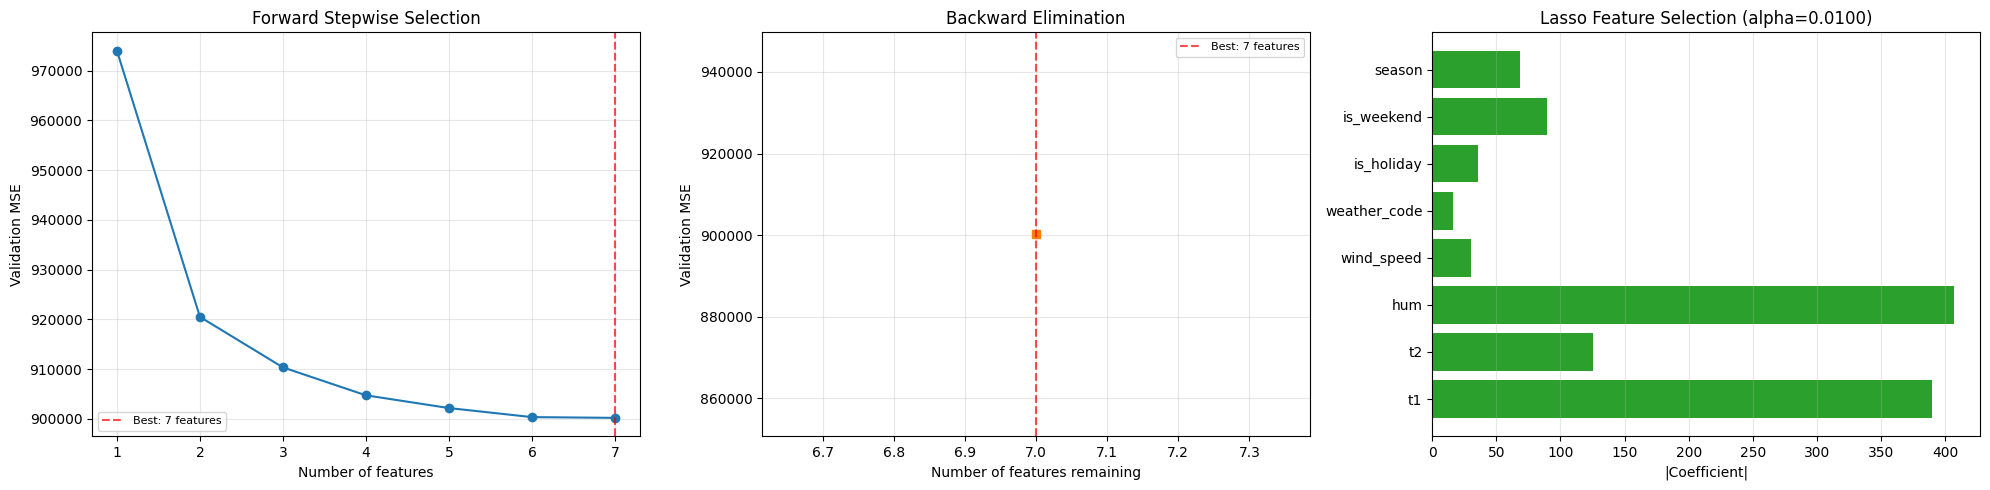


Feature selection comparison complete.


In [29]:
# So sanh 3 phuong phap Feature Selection
print('\n' + '=' * 60)
print(' So sanh ket qua Feature Selection')
print('=' * 60)

# --- Forward Stepwise ---
print('\n--- Forward Stepwise Selection ---')
fwd_results = forward_stepwise_selection(
    lambda: LinearRegression(solver='normal'),
    X_train, y_train, X_val, y_val, feature_names)
for r in fwd_results[:5]:
    print(f"  Step {r['step']}: +\"{r['feature_added']}\" -> Val MSE = {r['val_mse']:.2f}")
best_fwd = min(fwd_results, key=lambda x: x['val_mse']) if fwd_results else None
print('  ...')
if best_fwd:
    print(f"  Best: {best_fwd['step']} features -> {best_fwd['selected']}")

# --- Backward Elimination ---
print('\n--- Backward Elimination ---')
bwd_results = backward_elimination(
    lambda: LinearRegression(solver='normal'),
    X_train, y_train, X_val, y_val, feature_names)
for r in bwd_results[:5]:
    print(f"  Step {r['step']}: -\"{r['feature_removed']}\" -> Val MSE = {r['val_mse']:.2f}")
best_bwd = min(bwd_results, key=lambda x: x['val_mse']) if bwd_results else None
print('  ...')
if best_bwd:
    print(f"  Best: {len(best_bwd['remaining'])} features -> {best_bwd['remaining']}")

# --- Lasso-based ---
print('\n--- Lasso-based Feature Selection ---')
lasso_selected = [f for f, c in zip(feature_names, best_lasso.coef_) if c != 0]
lasso_dropped  = [f for f, c in zip(feature_names, best_lasso.coef_) if c == 0]
print(f'  Selected ({len(lasso_selected)}): {lasso_selected}')
print(f'  Dropped  ({len(lasso_dropped)}): {lasso_dropped}')

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Forward: x = number of features selected at each step
if fwd_results:
    fwd_mses = [r['val_mse'] for r in fwd_results]
    fwd_steps = [r['step'] for r in fwd_results]
    axes[0].plot(fwd_steps, fwd_mses, 'o-', markersize=6, color='#1f77b4')
    axes[0].axvline(best_fwd['step'], color='r', linestyle='--', alpha=0.7,
                    label=f"Best: {best_fwd['step']} features")
    axes[0].legend(fontsize=8)
axes[0].set_xlabel('Number of features')
axes[0].set_ylabel('Validation MSE')
axes[0].set_title('Forward Stepwise Selection')
axes[0].grid(alpha=0.3)

# Backward: x = number of features REMAINING after each step
# (starts at n_feat-1, decreases by 1 each step up to len(bwd_results) steps)
n_feat = len(feature_names)
if bwd_results:
    bwd_mses   = [r['val_mse'] for r in bwd_results]
    bwd_n_feat = list(range(n_feat - 1, n_feat - 1 - len(bwd_results), -1))  # descending
    axes[1].plot(bwd_n_feat, bwd_mses, 's-', markersize=6, color='#ff7f0e')
    axes[1].axvline(len(best_bwd['remaining']), color='r', linestyle='--', alpha=0.7,
                    label=f"Best: {len(best_bwd['remaining'])} features")
    axes[1].legend(fontsize=8)
axes[1].set_xlabel('Number of features remaining')
axes[1].set_ylabel('Validation MSE')
axes[1].set_title('Backward Elimination')
axes[1].grid(alpha=0.3)

# Lasso coefficients
colors = ['#2ca02c' if c != 0 else '#d62728' for c in best_lasso.coef_]
axes[2].barh(feature_names, np.abs(best_lasso.coef_), color=colors)
axes[2].set_xlabel('|Coefficient|')
axes[2].set_title(f'Lasso Feature Selection (alpha={best_alpha_lasso:.4f})')
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()
print('\nFeature selection comparison complete.')

## 3.3 Perceptron Regression (L2) và Logistic Regression có Regularization

In [30]:
# PerceptronRegression is imported from models/perceptron_reg.py


In [31]:
class LogisticRegressionReg:
    """Logistic Regression with L2 regularization.
    Binary classification: cnt > median → class 1, otherwise → class 0.
    """

    def __init__(self, learning_rate: float = LEARNING_RATE,
                 max_iter: int = MAX_ITER,
                 alpha: float = 0.01,
                 random_state: int = SEED):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.alpha = alpha
        self.random_state = random_state
        self.coef_ = None
        self.intercept_ = None
        self.loss_history_ = []

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        np.random.seed(self.random_state)
        n, d = X.shape
        self.coef_ = np.random.randn(d) * 0.01
        self.intercept_ = 0.0
        self.loss_history_ = []

        for _ in range(self.max_iter):
            h = self._sigmoid(X @ self.coef_ + self.intercept_)
            # Gradient with L2 penalty
            self.coef_ -= self.learning_rate * (
                (1 / n) * (X.T @ (h - y)) + 2 * self.alpha * self.coef_
            )
            self.intercept_ -= self.learning_rate * (1 / n) * np.sum(h - y)
            # Binary Cross-Entropy + L2
            eps = 1e-15
            bce = -np.mean(y * np.log(h + eps) + (1 - y) * np.log(1 - h + eps))
            self.loss_history_.append(bce + self.alpha * np.sum(self.coef_ ** 2))

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return self._sigmoid(X @ self.coef_ + self.intercept_)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return (self.predict_proba(X) >= 0.5).astype(int)

    def accuracy(self, X: np.ndarray, y: np.ndarray) -> float:
        return np.mean(self.predict(X) == y)

In [32]:
# Perceptron Regression (L2)
perc = PerceptronRegression(learning_rate=0.01, max_iter=5000, alpha=0.01)
perc.fit(X_train, y_train)

y_pred_perc = perc.predict(X_test)
m_perc = perc.evaluate(y_pred_perc, y_test)
print('Perceptron Regression (L2):', m_perc)

Perceptron Regression (L2): {'MSE': 898646.0884728814, 'RMSE': 947.9694554535401, 'MAE': 697.9204285777888, 'R2': 0.2500301620108596}


In [33]:
# Logistic Regression (L2) — binary: cnt > median
median_cnt = np.median(y_train)
y_train_bin = (y_train > median_cnt).astype(int)
y_val_bin   = (y_val   > median_cnt).astype(int)
y_test_bin  = (y_test  > median_cnt).astype(int)

log_reg = LogisticRegressionReg(learning_rate=0.01, max_iter=5000, alpha=0.01)
log_reg.fit(X_train, y_train_bin)

print('Logistic Regression (L2):')
print(f'  Train accuracy = {log_reg.accuracy(X_train, y_train_bin):.4f}')
print(f'  Val   accuracy = {log_reg.accuracy(X_val, y_val_bin):.4f}')
print(f'  Test  accuracy = {log_reg.accuracy(X_test, y_test_bin):.4f}')

Logistic Regression (L2):
  Train accuracy = 0.7351
  Val   accuracy = 0.7319
  Test  accuracy = 0.7321


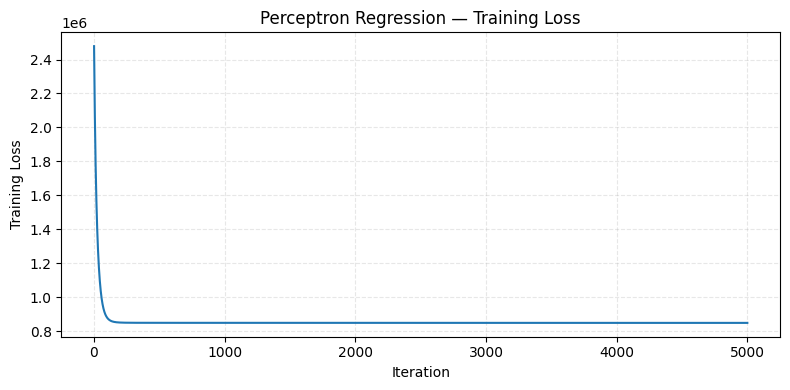

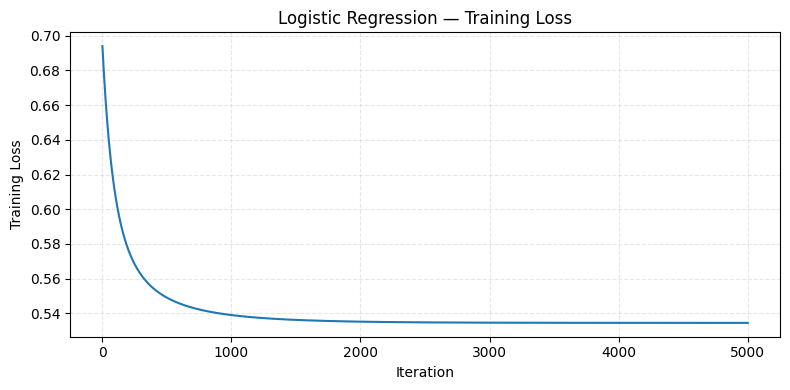

In [34]:
loss_curve(perc,    title='Perceptron Regression — Training Loss')
loss_curve(log_reg, title='Logistic Regression — Training Loss')


## 3.4 Kernel Ridge Regression

In [ ]:
# KernelRidgeRegression is imported from models/kernel_ridge.py


In [35]:
# Giới hạn mẫu để tránh tốn bộ nhớ (kernel matrix n×n)
N_KRR = min(3000, X_train.shape[0])
X_tr_krr = X_train[:N_KRR]
y_tr_krr = y_train[:N_KRR]

print('--- KRR tuning ---')
best_krr = None
best_params_krr = None
best_mse_krr = float('inf')

for alpha in [0.1, 1.0, 10.0]:
    for gamma in [0.01, 0.1, 1.0]:
        model = KernelRidgeRegression(alpha=alpha, gamma=gamma)
        model.fit(X_tr_krr, y_tr_krr)
        mse_val = model.evaluate(model.predict(X_val), y_val)['MSE']
        print(f'  alpha={alpha:<5}  gamma={gamma:<5}  val MSE={mse_val:.2f}')
        if mse_val < best_mse_krr:
            best_mse_krr = mse_val
            best_params_krr = (alpha, gamma)
            best_krr = model

y_pred_krr = best_krr.predict(X_test)
m_krr = best_krr.evaluate(y_pred_krr, y_test)
print(f'\nBest KRR (alpha={best_params_krr[0]}, gamma={best_params_krr[1]}): {m_krr}')

--- KRR tuning ---
  alpha=0.1    gamma=0.01   val MSE=854601.31
  alpha=0.1    gamma=0.1    val MSE=831354.23
  alpha=0.1    gamma=1.0    val MSE=952030.95
  alpha=1.0    gamma=0.01   val MSE=866576.87
  alpha=1.0    gamma=0.1    val MSE=840921.48
  alpha=1.0    gamma=1.0    val MSE=849673.24
  alpha=10.0   gamma=0.01   val MSE=887532.81
  alpha=10.0   gamma=0.1    val MSE=850929.19
  alpha=10.0   gamma=1.0    val MSE=1031227.75

Best KRR (alpha=0.1, gamma=0.1): {'MSE': 834622.3982748835, 'RMSE': 913.5767062895613, 'MAE': 650.9967678682743, 'R2': 0.3034614707108789}


---
# 4. Bias–Variance & VC Dimension <a id='4'></a>

## 4.1 Bias–Variance thực nghiệm (Bootstrap)

Mục tiêu: ước lượng $\text{Bias}^2$, $\text{Variance}$ và $\text{Noise}$ bằng bootstrap trên tập train, đánh giá trên tập test.

Công thức:
- $\text{Bias}^2 = \mathbb{E}[(y - \mathbb{E}[\hat{y}])^2]$
- $\text{Variance} = \mathbb{E}[\text{Var}(\hat{y})]$
- $\text{Noise} \approx \max(\text{MSE}_{\text{full}} - \text{Bias}^2 - \text{Variance}, 0)$


           bias2    variance         noise            mse              model
0  897862.684317  444.300421  1.875264e-10  898306.984738  Linear Regression
1  954559.263809  291.487569  0.000000e+00  954850.751378     Robust (Huber)


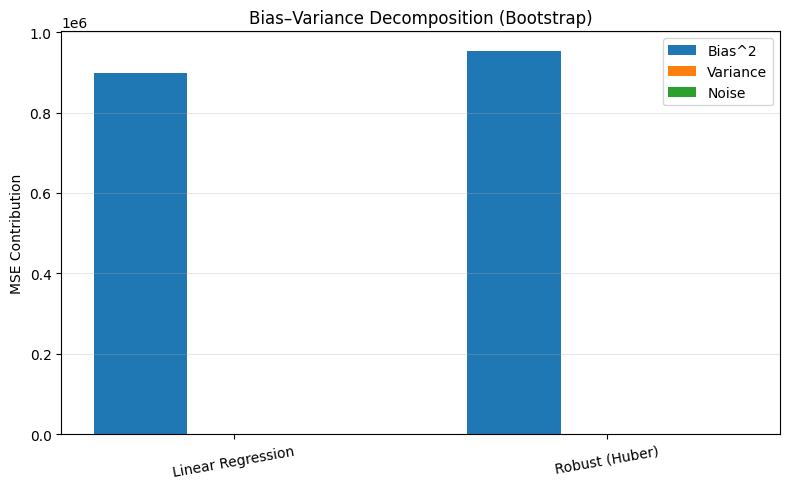

In [36]:
bv_models = {
    "Linear Regression": lambda: LinearRegression(solver="normal"),
    "Robust (Huber)": lambda: Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("huber", HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=1000)),
        ]
    ),
}

bv_rows = []
for name, builder in bv_models.items():
    res = bias_variance_bootstrap(builder, X_train, y_train, X_test, y_test, n_boot=30)
    res["model"] = name
    bv_rows.append(res)

bv_df = pd.DataFrame(bv_rows)
print(bv_df)

x = np.arange(len(bv_df))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, bv_df["bias2"], width, label="Bias^2")
plt.bar(x, bv_df["variance"], width, label="Variance")
plt.bar(x + width, bv_df["noise"], width, label="Noise")
plt.xticks(x, bv_df["model"], rotation=10)
plt.ylabel("MSE Contribution")
plt.title("Bias–Variance Decomposition (Bootstrap)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 4.2 VC Dimension (Phân tích lý thuyết)

- Với mô hình tuyến tính có $d$ đặc trưng (đã chuẩn hoá), **pseudo-dimension** xấp xỉ $d+1$. Điều này phản ánh khả năng biểu diễn tăng tuyến tính theo số đặc trưng.
- Nếu dùng đa thức bậc $k$ trong $d$ chiều, số đặc trưng sinh ra là:

$$\binom{d + k}{k}$$

Tức là độ phức tạp (và VC dimension) tăng rất nhanh theo $k$.

**Kết luận:**
- Mô hình càng phức tạp (nhiều đặc trưng/phi tuyến) → VC dimension cao → nguy cơ overfitting tăng.
- Cần regularization hoặc chọn feature để kiểm soát độ phức tạp.


---
# 5. Evaluate & Visualization <a id='5'></a>

## 5.1 10-fold CV + Bảng kết quả thống nhất

Chạy k-fold CV (k=10) cho tất cả mô hình regression và báo cáo mean ± std cho MSE/RMSE/MAE/R2.
Ghi chú: Kernel Ridge dùng subset để tránh ma trận kernel quá lớn.

In [37]:
cv_X = X_scaled
cv_y = y

cv_models = {
    "Linear Regression": lambda: LinearRegression(solver="normal"),
    "Robust (Huber)": lambda: Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("huber", HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=1000)),
        ]
    ),
    "Robust (RANSAC)": lambda: Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("ransac", RANSACRegressor(estimator=SkLinearRegression(), random_state=SEED)),
        ]
    ),
    "Ridge Regression": lambda: RidgeRegression(alpha=best_alpha_ridge),
    "Lasso Regression": lambda: LassoRegression(alpha=best_alpha_lasso),
    "Elastic Net": lambda: ElasticNetRegression(lambda1=best_l1, lambda2=best_l2, max_iter=1000),
    "Perceptron (L2)": lambda: PerceptronRegression(learning_rate=0.01, max_iter=5000, alpha=0.01),
}

cv_rows = []
for name, builder in cv_models.items():
    res = k_fold_cv_metrics(builder, cv_X, cv_y, k=10)
    cv_rows.append(
        {
            "Model": name,
            "MSE (mean±std)": f"{res['mse'][0]:.2f} ± {res['mse'][1]:.2f}",
            "RMSE (mean±std)": f"{res['rmse'][0]:.2f} ± {res['rmse'][1]:.2f}",
            "MAE (mean±std)": f"{res['mae'][0]:.2f} ± {res['mae'][1]:.2f}",
            "R2 (mean±std)": f"{res['r2'][0]:.4f} ± {res['r2'][1]:.4f}",
            "rmse_mean": res["rmse"][0],
        }
    )

krr_n = min(2000, len(cv_X))
cv_X_krr = cv_X[:krr_n]
cv_y_krr = cv_y[:krr_n]

krr_res = k_fold_cv_metrics(
    lambda: KernelRidgeRegression(alpha=best_params_krr[0], gamma=best_params_krr[1]),
    cv_X_krr,
    cv_y_krr,
    k=10,
)
cv_rows.append(
    {
        "Model": "Kernel Ridge (subset)",
        "MSE (mean±std)": f"{krr_res['mse'][0]:.2f} ± {krr_res['mse'][1]:.2f}",
        "RMSE (mean±std)": f"{krr_res['rmse'][0]:.2f} ± {krr_res['rmse'][1]:.2f}",
        "MAE (mean±std)": f"{krr_res['mae'][0]:.2f} ± {krr_res['mae'][1]:.2f}",
        "R2 (mean±std)": f"{krr_res['r2'][0]:.4f} ± {krr_res['r2'][1]:.4f}",
        "rmse_mean": krr_res["rmse"][0],
    }
)

cv_table = pd.DataFrame(cv_rows).sort_values("rmse_mean").drop(columns=["rmse_mean"])
cv_table

,Model,MSE (mean±std),RMSE (mean±std),MAE (mean±std),R2 (mean±std)
7,Kernel Ridge (subset),555144.62 ± 69827.67,743.58 ± 47.24,527.91 ± 33.30,0.1989 ± 0.0385
3,Ridge Regression,862152.54 ± 34879.28,928.33 ± 18.75,688.70 ± 9.37,0.2676 ± 0.0149
4,Lasso Regression,862154.51 ± 34858.23,928.33 ± 18.73,688.70 ± 9.38,0.2676 ± 0.0149
0,Linear Regression,862154.53 ± 34857.51,928.33 ± 18.73,688.70 ± 9.38,0.2676 ± 0.0149
6,Perceptron (L2),862500.32 ± 35053.20,928.52 ± 18.83,689.00 ± 9.30,0.2673 ± 0.0148
5,Elastic Net,864971.90 ± 35225.77,929.85 ± 18.89,691.60 ± 9.31,0.2652 ± 0.0139
1,Robust (Huber),910980.83 ± 43224.19,954.18 ± 22.63,649.00 ± 10.64,0.2263 ± 0.0178
2,Robust (RANSAC),1110994.01 ± 116377.39,1052.60 ± 55.09,706.85 ± 39.27,0.0579 ± 0.0745


## 5.2 Paired statistical tests (t-test / Wilcoxon)

So sánh từng mô hình với mô hình tốt nhất (theo RMSE) bằng kiểm định cặp trên 10 folds.
Báo cáo p-value và kết luận ý nghĩa thống kê với $\alpha = 0.05$.

In [38]:
splits = build_kfold_indices(len(cv_y), k=10, random_state=SEED)

rmse_per_model = {}
for name, builder in cv_models.items():
    rmse_per_model[name] = kfold_rmse_per_model(builder, cv_X, cv_y, splits)

krr_splits = build_kfold_indices(len(cv_y_krr), k=10, random_state=SEED)
rmse_per_model["Kernel Ridge (subset)"] = kfold_rmse_per_model(
    lambda: KernelRidgeRegression(alpha=best_params_krr[0], gamma=best_params_krr[1]),
    cv_X_krr,
    cv_y_krr,
    krr_splits,
)

stats_df = paired_tests_against_best(rmse_per_model)
stats_df

,Model,Mean RMSE,Std RMSE,vs_best,t_pvalue,wilcoxon_pvalue,significant
0,Kernel Ridge (subset),743.5812,47.2397,Kernel Ridge (subset),1.0,1.000,False
1,Ridge Regression,928.3325,18.7451,Kernel Ridge (subset),0.0,0.002,True
2,Lasso Regression,928.3337,18.7342,Kernel Ridge (subset),0.0,0.002,True
3,Linear Regression,928.3338,18.7339,Kernel Ridge (subset),0.0,0.002,True
4,Perceptron (L2),928.5180,18.8308,Kernel Ridge (subset),0.0,0.002,True
5,Elastic Net,929.8467,18.8929,Kernel Ridge (subset),0.0,0.002,True
6,Robust (Huber),954.1848,22.6327,Kernel Ridge (subset),0.0,0.002,True
7,Robust (RANSAC),1052.5963,55.0915,Kernel Ridge (subset),0.0,0.002,True


In [39]:
# Compare all models on the test set
all_results = {
    'Linear Regression':  m_lr,
    'Robust (Huber)':     m_huber,
    'Robust (RANSAC)':    m_ransac,
    'Ridge Regression':   m_ridge,
    'Lasso Regression':   m_lasso,
    'Elastic Net':        m_enet,
    'Perceptron (L2)':    m_perc,
    'Kernel Ridge (RBF)': m_krr,
}

print(f"{'Model':<25} {'MSE':>10} {'RMSE':>10} {'MAE':>10} {'R2':>10}")
print('=' * 67)
for name, met in sorted(all_results.items(), key=lambda x: x[1]['RMSE']):
    print(f"{name:<25} {met['MSE']:>10.2f} {met['RMSE']:>10.2f} "
          f"{met['MAE']:>10.2f} {met['R2']:>10.4f}")


Model                            MSE       RMSE        MAE         R2
Kernel Ridge (RBF)         834622.40     913.58     651.00     0.3035
Linear Regression          898089.19     947.68     697.80     0.2505
Lasso Regression           898090.24     947.68     697.80     0.2505
Ridge Regression           898123.75     947.69     697.77     0.2505
Perceptron (L2)            898646.09     947.97     697.92     0.2500
Elastic Net                900335.60     948.86     700.77     0.2486
Robust (Huber)             954938.36     977.21     660.35     0.2031
Robust (RANSAC)           1007684.71    1003.84     666.33     0.1590


## 5.3 Learning Curves

In [ ]:
# plot_learning_curves được import từ utils.py

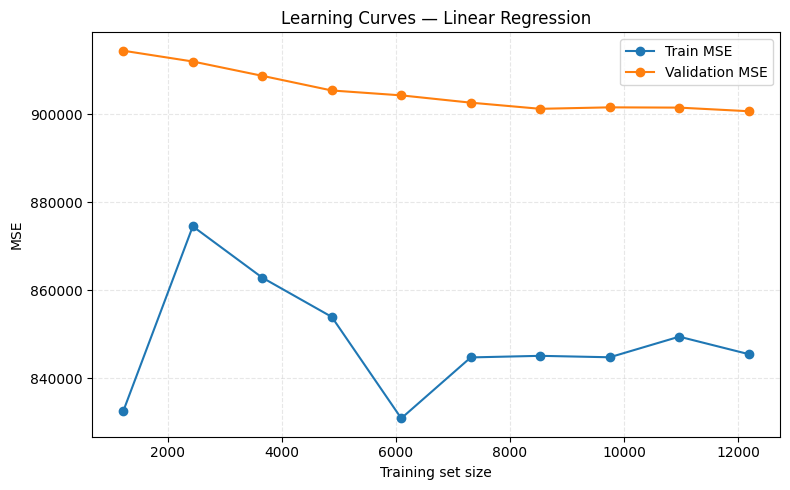

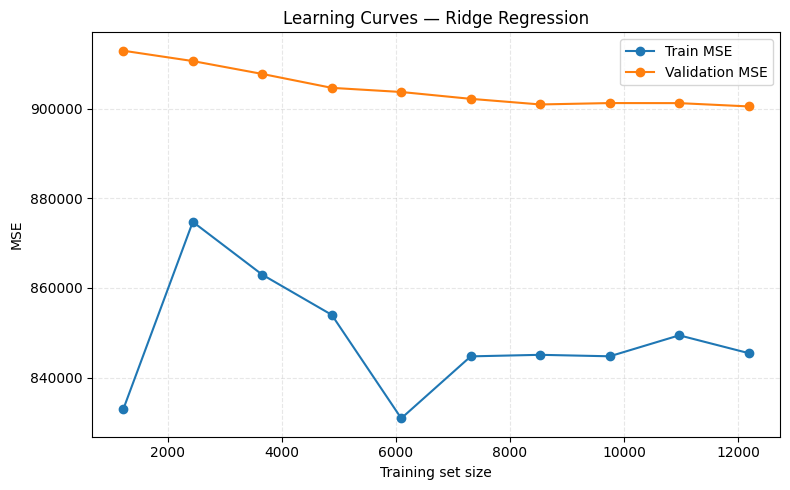

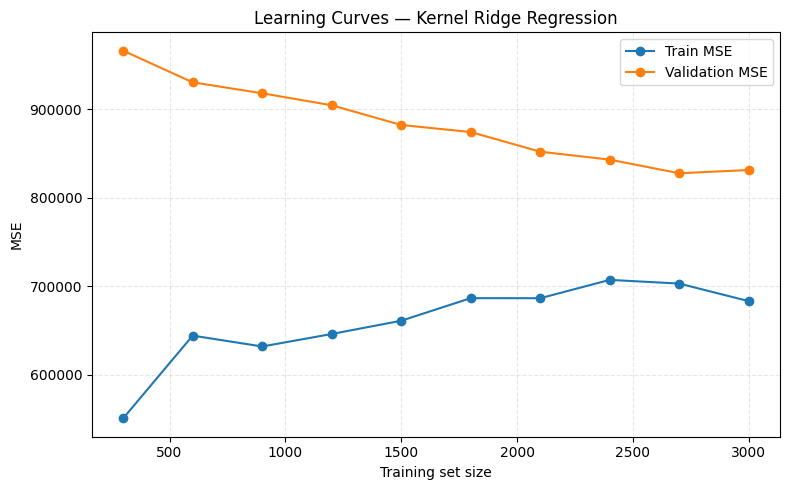

In [40]:
plot_learning_curves(
    LinearRegression, {'solver': 'normal'},
    X_train_raw, y_train, X_val_raw, y_val,
    title='Learning Curves — Linear Regression',
    ScalerClass=StandardScaler,
)

plot_learning_curves(
    RidgeRegression, {'alpha': best_alpha_ridge},
    X_train_raw, y_train, X_val_raw, y_val,
    title='Learning Curves — Ridge Regression',
    ScalerClass=StandardScaler,
)

plot_learning_curves(
    KernelRidgeRegression,
    {'alpha': best_params_krr[0], 'gamma': best_params_krr[1]},
    X_train_raw[:N_KRR], y_tr_krr, X_val_raw, y_val,
    title='Learning Curves — Kernel Ridge Regression',
    ScalerClass=StandardScaler,
)

## 5.4 Biểu đồ phần dư (Residuals)

In [ ]:
# plot_residuals được import từ utils.py

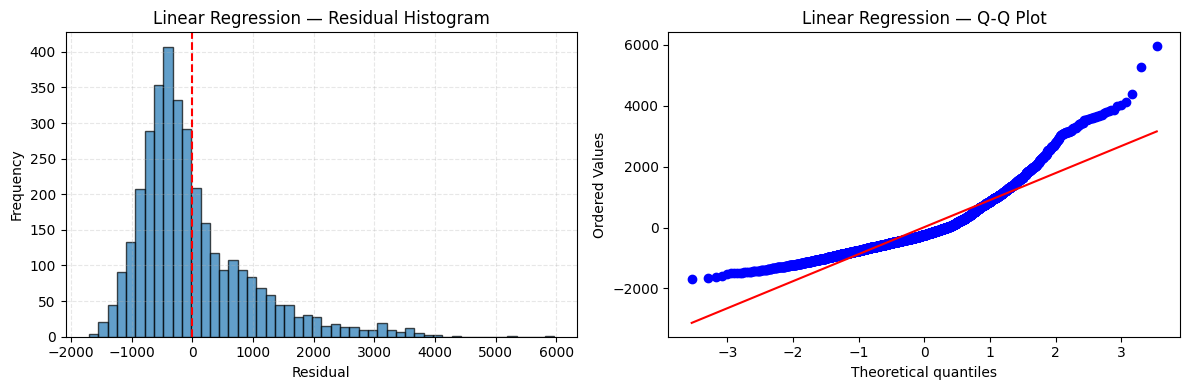

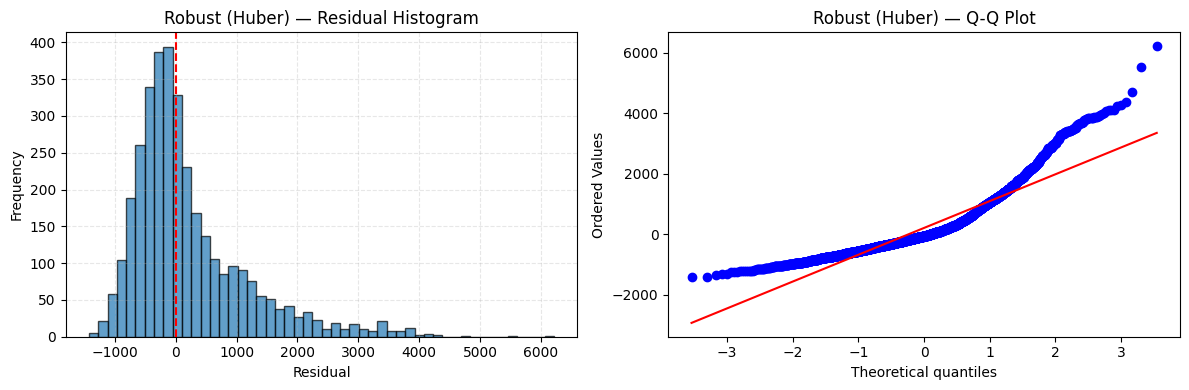

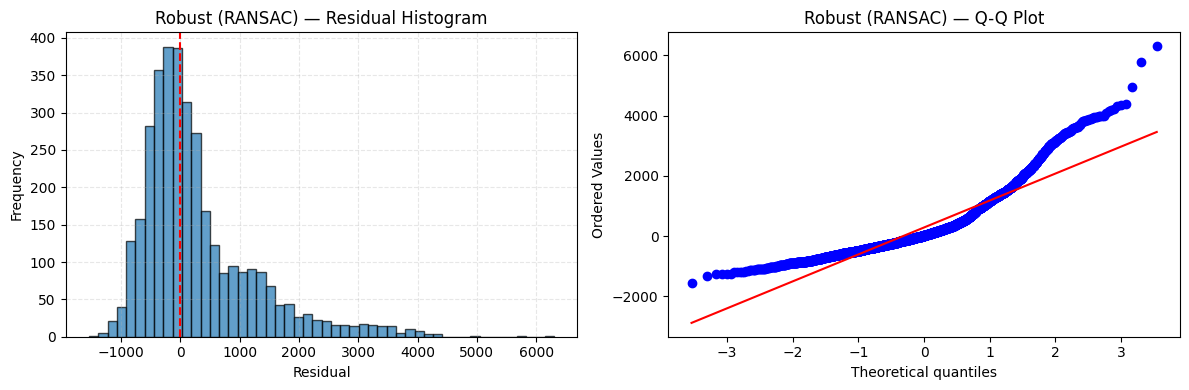

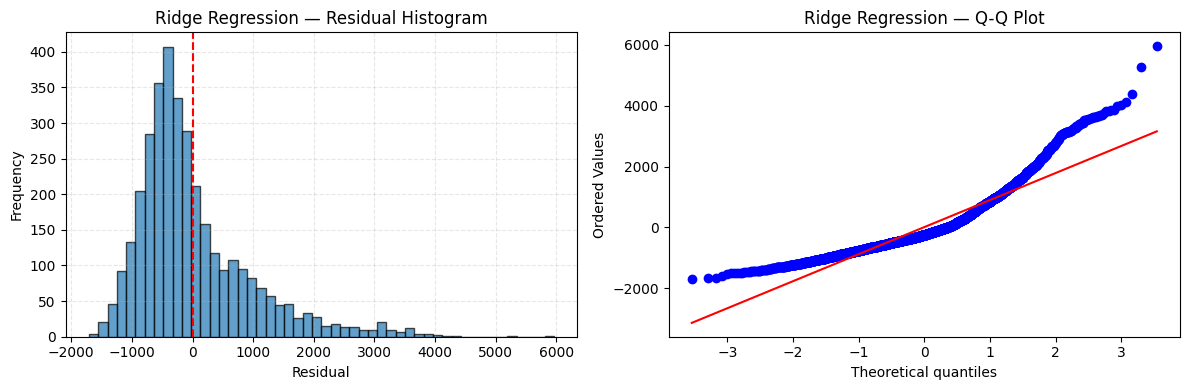

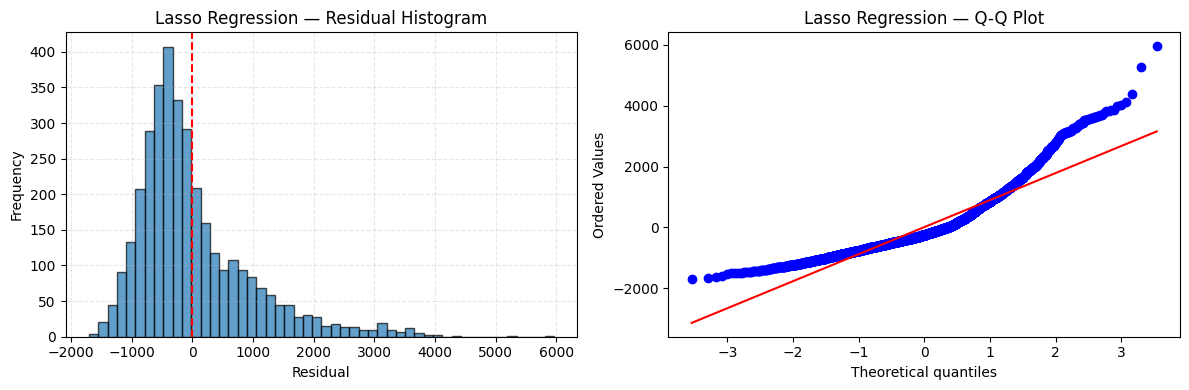

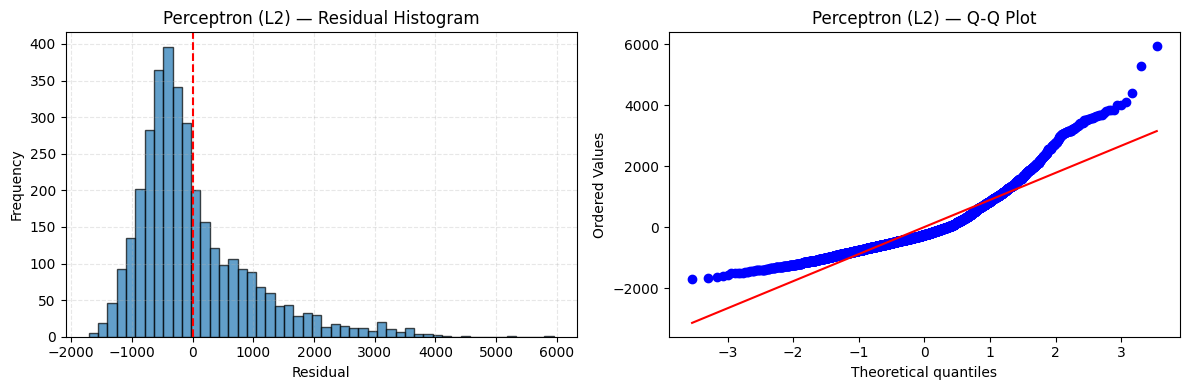

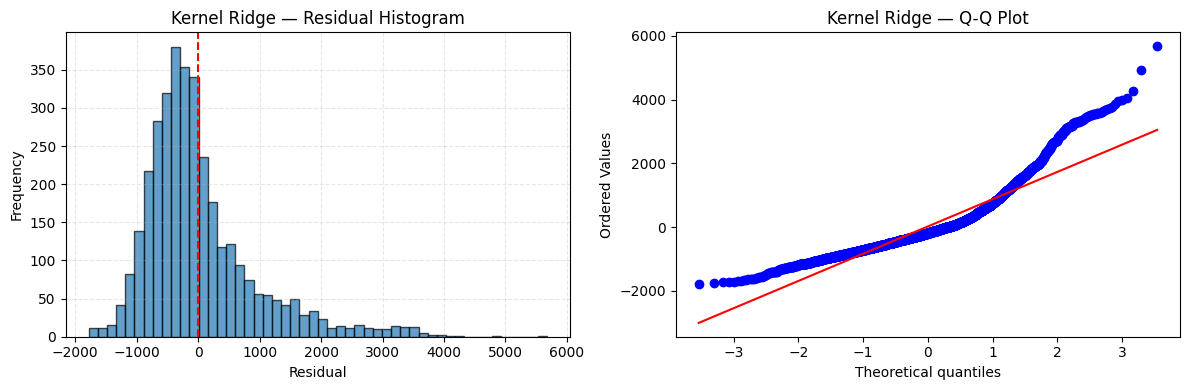

In [41]:
models_pred = [
    ('Linear Regression', y_pred_lr),
    ('Robust (Huber)',    y_pred_huber),
    ('Robust (RANSAC)',   y_pred_ransac),
    ('Ridge Regression',  y_pred_ridge),
    ('Lasso Regression',  y_pred_lasso),
    ('Perceptron (L2)',   y_pred_perc),
    ('Kernel Ridge',      y_pred_krr),
]

for name, y_pred in models_pred:
    plot_residuals(y_test, y_pred, title=name)

## 5.5 Predicted vs. Actual

In [ ]:
# plot_predicted_vs_actual được import từ utils.py

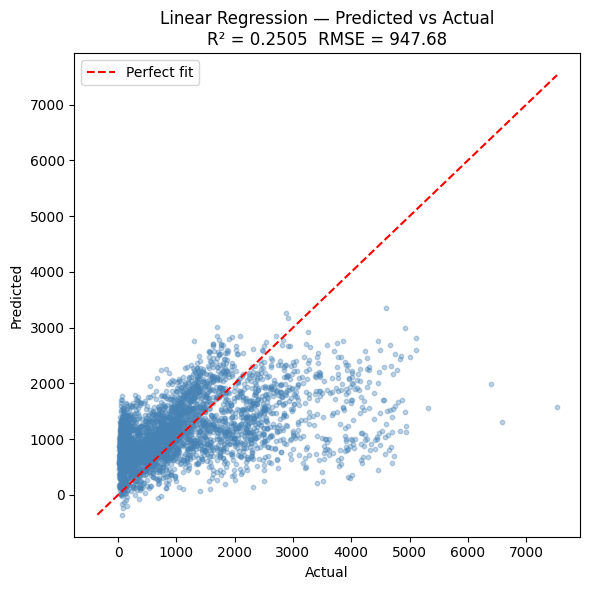

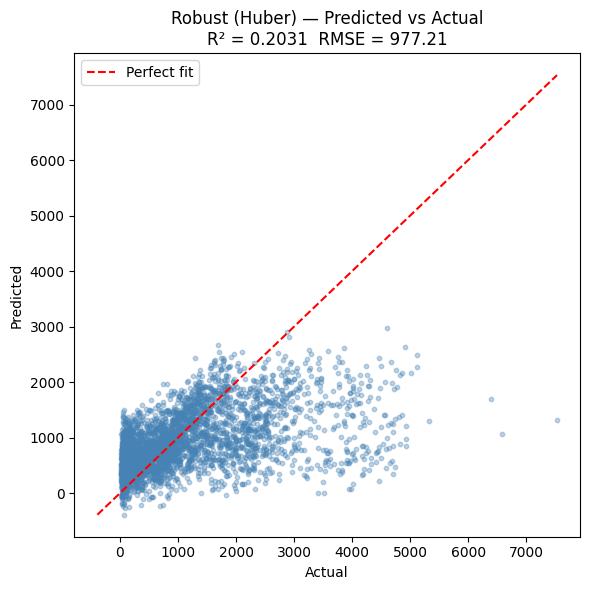

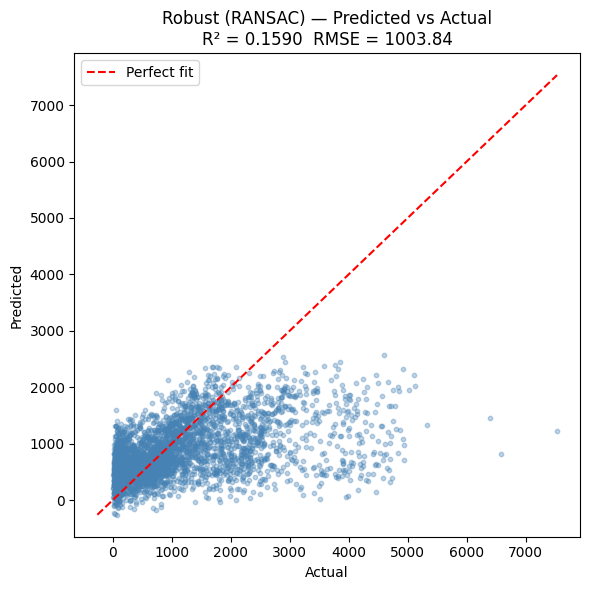

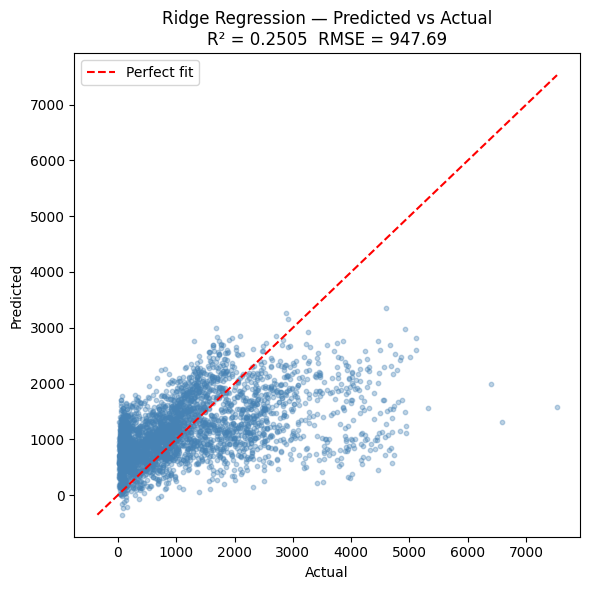

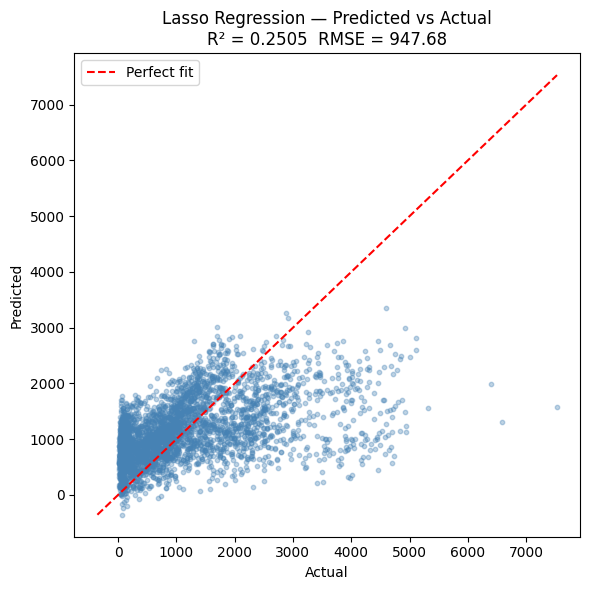

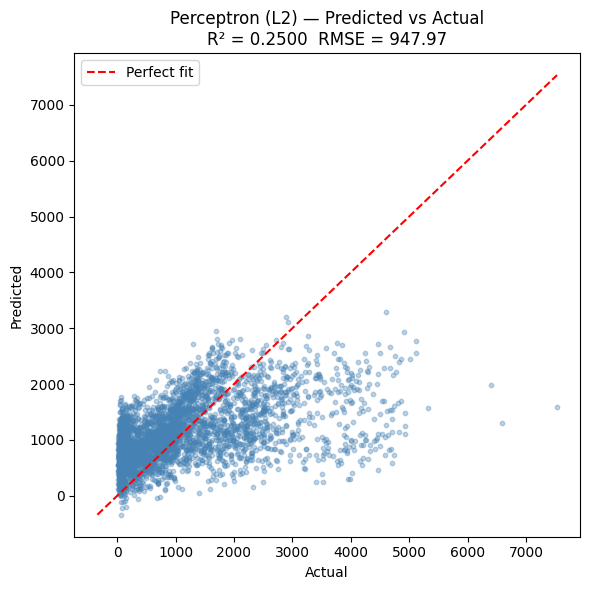

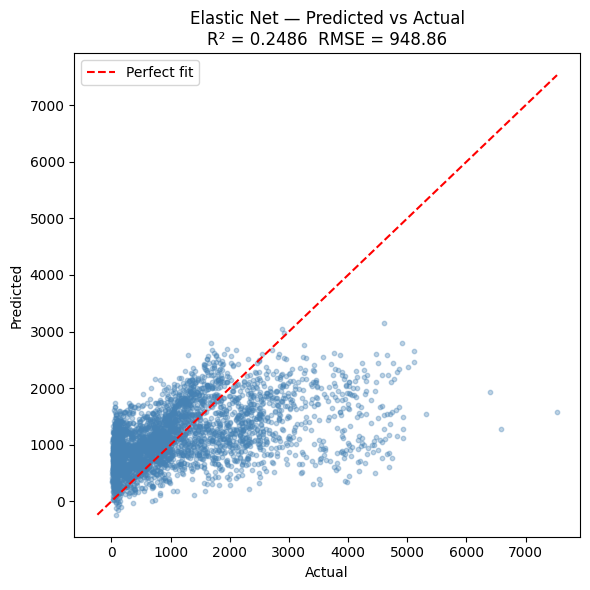

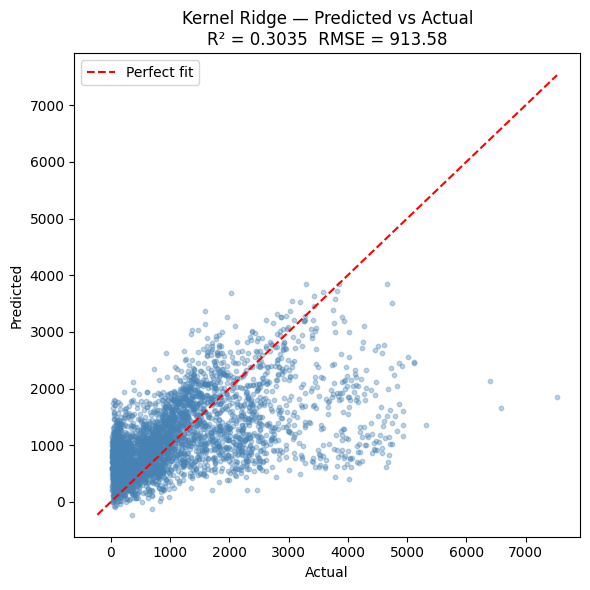

In [42]:
# Tạo danh sách các mô hình và dự đoán
models_pred = [
    ('Linear Regression', y_pred_lr),
    ('Robust (Huber)',    y_pred_huber),
    ('Robust (RANSAC)',   y_pred_ransac),
    ('Ridge Regression',  y_pred_ridge),
    ('Lasso Regression',  y_pred_lasso),
    ('Perceptron (L2)',   y_pred_perc),
    ('Elastic Net',       y_test_pred_enet),
    ('Kernel Ridge',      y_pred_krr),
]

for name, y_pred in models_pred:
    plot_predicted_vs_actual(y_test, y_pred, title=f'{name} — Predicted vs Actual')